# 📊 Индивидуальная групповая работа 2
## Продвинутый статистический анализ данных об энергии и методы машинного обучения

**Тема:** Анализ потребления и производства электроэнергии в Испании (2015–2018)

**Источник данных:** Kaggle — *Hourly Energy Demand Generation and Weather*

**Авторы:** *заполнить ФИО*

---

## I. Введение и обоснование темы

### 1.1 О чём эта работа и зачем она нужна

Представьте, что вы управляете электростанцией. Каждую секунду вам нужно производить ровно столько электроэнергии, сколько люди потребляют — не больше и не меньше. Если слишком мало — погаснет свет. Если слишком много — лишняя энергия тратится впустую.

Именно поэтому каждый оператор электросети каждый день решает задачу: **сколько электроэнергии понадобится через час, через день, через неделю?**

В этой работе мы анализируем реальные данные об электроэнергетике **Испании за 2015–2018 годы** и строим модели, которые умеют:
- предсказывать потребление энергии на следующий час;
- определять, будет ли нагрузка высокой или низкой;
- прогнозировать потребление на несколько дней вперёд.

---

### 1.2 Почему именно Испания

Испания — один из крупнейших производителей **возобновляемой энергии** в Европе. Ветряные фермы на севере, солнечные панели на юге. Доля ВИЭ > 30%. Кроме того, электроэнергия торгуется на **открытом рынке** — цена меняется каждый час.

---

### 1.3 Цели анализа

1. Исследовать закономерности в потреблении (суточные, недельные, сезонные).
2. Построить **линейную регрессию** для прогноза почасового потребления.
3. Построить **логистическую регрессию** для классификации пиков нагрузки.
4. Применить **PCA** для снижения размерности и улучшения моделей.
5. Построить модель **ARIMA** для краткосрочного прогноза.

---

### 1.4 Описание наборов данных

#### energy_dataset.csv
- **Источник:** ENTSO-E | **Период:** 2015–2018 | **Строк:** 35 064 (1 строка = 1 час)
- `total load actual` — фактическое потребление (MW) ← **целевая переменная**
- `price actual` — рыночная цена (EUR/MWh)
- `generation solar` / `generation wind onshore` — ВИЭ-генерация (MW)

#### weather_features.csv
- **Источник:** OpenWeatherMap | **Города:** Мадрид, Барселона, Валенсия, Севилья, Бильбао
- `temp` (K), `humidity` (%), `pressure` (гПа), `wind_speed` (м/с), `clouds_all` (%)

#### Почему погода важна?
- Жарко → кондиционеры → потребление ↑
- Холодно → обогреватели → потребление ↑
- Ветрено/солнечно → больше ВИЭ → меньше нужно традиционных источников

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    accuracy_score, classification_report, confusion_matrix
)
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 10
})
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

energy  = pd.read_csv('energy_dataset.csv')
weather = pd.read_csv('weather_features.csv')

print('=== energy_dataset.csv ===')
print(f'Строк: {energy.shape[0]},  Столбцов: {energy.shape[1]}')
print(energy.head(3))

print('\n=== weather_features.csv ===')
print(f'Строк: {weather.shape[0]},  Столбцов: {weather.shape[1]}')
print(weather.head(3))

=== energy_dataset.csv ===
Строк: 35064,  Столбцов: 29
                        time  generation biomass  \
0  2015-01-01 00:00:00+01:00               447.0   
1  2015-01-01 01:00:00+01:00               449.0   
2  2015-01-01 02:00:00+01:00               448.0   

   generation fossil brown coal/lignite  generation fossil coal-derived gas  \
0                                 329.0                                 0.0   
1                                 328.0                                 0.0   
2                                 323.0                                 0.0   

   generation fossil gas  generation fossil hard coal  generation fossil oil  \
0                 4844.0                       4821.0                  162.0   
1                 5196.0                       4755.0                  158.0   
2                 4857.0                       4581.0                  157.0   

   generation fossil oil shale  generation fossil peat  generation geothermal  \
0                

## II. Предобработка и очистка данных

### 2.1 Объединение датасетов
Данные об энергии и погоде хранятся в отдельных файлах. Объединяем по временной метке. Погодные данные по пяти городам усредняются.

### 2.2 Обработка пропущенных значений
Пропуски заполняем **медианой** — она устойчива к выбросам.

### 2.3 Обработка выбросов методом IQR
**IQR** = Q3 − Q1. Значения за пределами [Q1 − 3·IQR, Q3 + 3·IQR] обрезаются. k=3 выбрано намеренно: убираем только технические ошибки.

### 2.4 Создание новых признаков
Из временной метки: **час суток, день недели, месяц, признак выходного**.

In [2]:
energy['time']    = pd.to_datetime(energy['time'],    utc=True)
weather['dt_iso'] = pd.to_datetime(weather['dt_iso'], utc=True)

w_agg = weather.groupby('dt_iso').agg({
    'temp':'mean', 'pressure':'mean', 'humidity':'mean',
    'wind_speed':'mean', 'rain_1h':'mean', 'clouds_all':'mean'
}).reset_index()

df = energy.merge(w_agg, left_on='time', right_on='dt_iso', how='left')

print('Пропуски до обработки (топ-10):')
missing_before = df.isnull().sum().sort_values(ascending=False)
print(missing_before[missing_before > 0].head(10))

num_cols = df.select_dtypes(include=[np.number]).columns
for c in num_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].median())

cols_drop = [c for c in df.columns if df[c].isna().all()]
df = df.drop(columns=cols_drop + ['dt_iso'])

def cap_iqr(s, k=3.0):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return s.clip(q1 - k*iqr, q3 + k*iqr)

for c in ['total load actual','price actual','generation solar','generation wind onshore']:
    if c in df.columns:
        df[c] = cap_iqr(df[c])

df['hour']        = df['time'].dt.hour
df['day_of_week'] = df['time'].dt.dayofweek
df['month']       = df['time'].dt.month
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)
df['temp_c']      = df['temp'] - 273.15

print(f'\nПропуски после обработки: {df.isna().sum().sum()}')
print(f'Итоговый датасет: {df.shape[0]} строк, {df.shape[1]} столбцов')
print(df[['time','total load actual','price actual','temp_c','hour','is_weekend']].head(5))

Пропуски до обработки (топ-10):
forecast wind offshore eday ahead              35064
generation hydro pumped storage aggregated     35064
total load actual                                 36
generation biomass                                19
generation marine                                 19
generation waste                                  19
generation hydro pumped storage consumption       19
generation fossil oil                             19
generation hydro run-of-river and poundage        19
generation wind onshore                           18
dtype: int64

Пропуски после обработки: 0
Итоговый датасет: 35064 строк, 38 столбцов
                       time  total load actual  price actual    temp_c  hour  \
0 2014-12-31 23:00:00+00:00            25385.0         65.41 -0.658537    23   
1 2015-01-01 00:00:00+00:00            24382.0         64.92 -0.637300     0   
2 2015-01-01 01:00:00+00:00            22734.0         64.48 -1.050862     1   
3 2015-01-01 02:00:00+00:00      

### 2.5 Визуализация пропусков и распределений

Первый график — в каких столбцах было больше всего пропусков. Второй — распределения ключевых переменных после очистки.

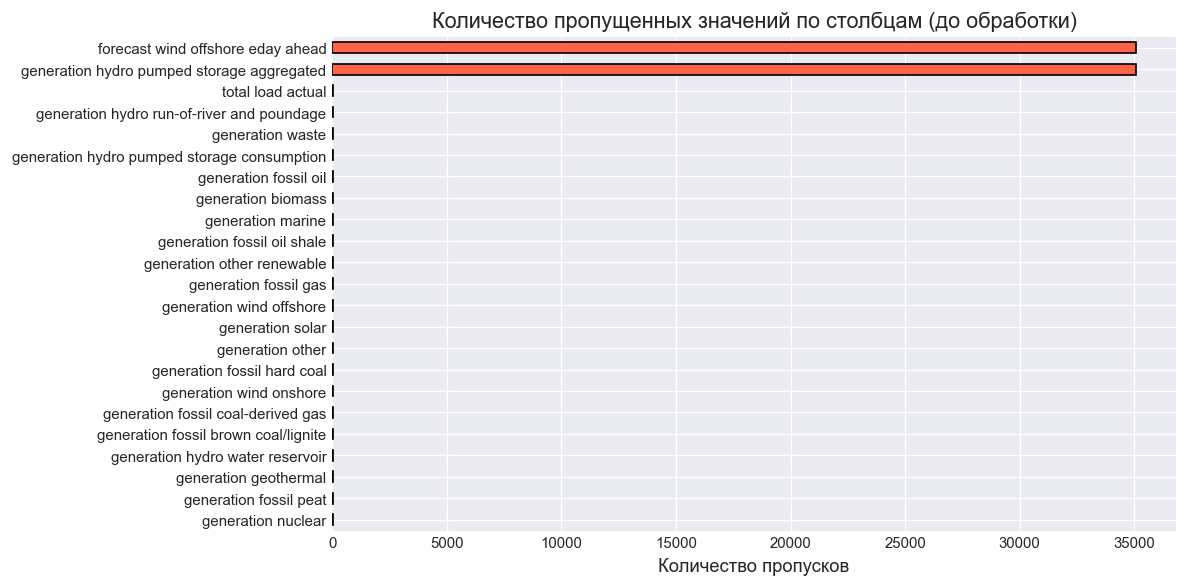

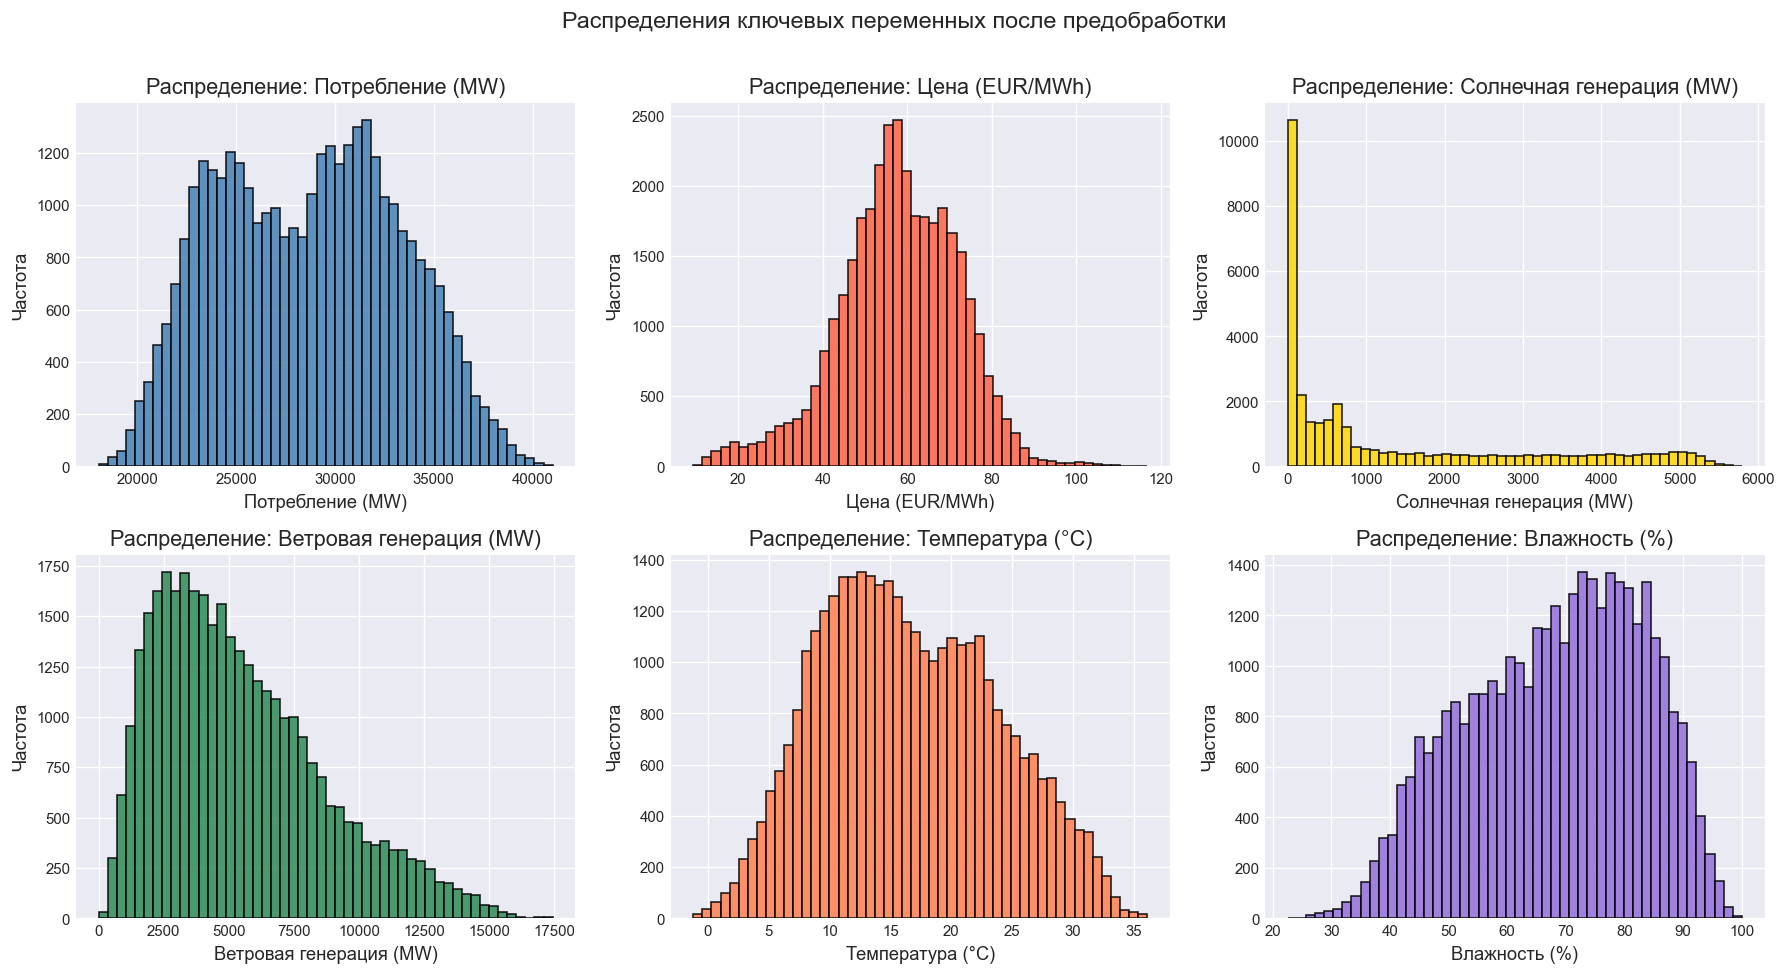

In [3]:
missing_plot = missing_before[missing_before > 0].sort_values()
if len(missing_plot) > 0:
    plt.figure(figsize=(10, 5))
    missing_plot.plot(kind='barh', color='tomato', edgecolor='black')
    plt.title('Количество пропущенных значений по столбцам (до обработки)')
    plt.xlabel('Количество пропусков')
    plt.tight_layout()
    plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cols_dist = ['total load actual','price actual','generation solar',
             'generation wind onshore','temp_c','humidity']
titles    = ['Потребление (MW)','Цена (EUR/MWh)','Солнечная генерация (MW)',
             'Ветровая генерация (MW)','Температура (°C)','Влажность (%)']
colors    = ['steelblue','tomato','gold','seagreen','coral','mediumpurple']

for ax, col, title, color in zip(axes.flatten(), cols_dist, titles, colors):
    ax.hist(df[col].dropna(), bins=50, color=color, edgecolor='black', alpha=0.85)
    ax.set_title(f'Распределение: {title}')
    ax.set_xlabel(title)
    ax.set_ylabel('Частота')

plt.suptitle('Распределения ключевых переменных после предобработки', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## III. Исследовательский анализ данных (EDA)

**EDA** — разведка данных: ищем закономерности, проверяем гипотезы.

### 3.1 Описательная статистика

- **mean** — среднее | **std** — стандартное отклонение
- **min / max** — минимум и максимум
- **25% / 50% / 75%** — квартили (медиана = 50%)

In [4]:
keys = ['total load actual','price actual','generation solar',
        'generation wind onshore','temp_c','humidity','pressure','wind_speed']
labels = {
    'total load actual':'Потребление (MW)', 'price actual':'Цена (EUR/MWh)',
    'generation solar':'Солнечная (MW)', 'generation wind onshore':'Ветровая (MW)',
    'temp_c':'Темп-ра (°C)', 'humidity':'Влажность (%)',
    'pressure':'Давление (гПа)', 'wind_speed':'Скорость ветра (м/с)'
}
desc = df[keys].describe().T.round(2)
desc.index = [labels.get(i, i) for i in desc.index]
print(desc)

                        count      mean      std       min       25%  \
Потребление (MW)      35064.0  28697.15  4572.64  18041.00  24810.00   
Цена (EUR/MWh)        35064.0     57.88    14.20      9.33     49.35   
Солнечная (MW)        35064.0   1432.25  1679.79      0.00     71.00   
Ветровая (MW)         35064.0   5464.16  3212.90      0.00   2933.75   
Темп-ра (°C)          35064.0     16.53     7.26     -1.21     10.91   
Влажность (%)         35064.0     68.22    14.89     22.60     56.80   
Давление (гПа)        35064.0   1070.21  2692.27    812.40   1012.80   
Скорость ветра (м/с)  35064.0      2.47     1.36      0.00      1.40   

                           50%       75%        max  
Потребление (MW)      28901.00  32186.25   41015.00  
Цена (EUR/MWh)           58.02     68.01     116.80  
Солнечная (MW)          616.00   2575.25    5792.00  
Ветровая (MW)          4849.00   7397.00   17436.00  
Темп-ра (°C)             15.88     21.94      36.12  
Влажность (%)            69

### 3.2 Потребление во времени (2015–2018)

Первый важный график — как менялось потребление за весь период. Видны **сезонные паттерны** (зима/лето). Скользящее среднее за 30 дней показывает тренд без шума.

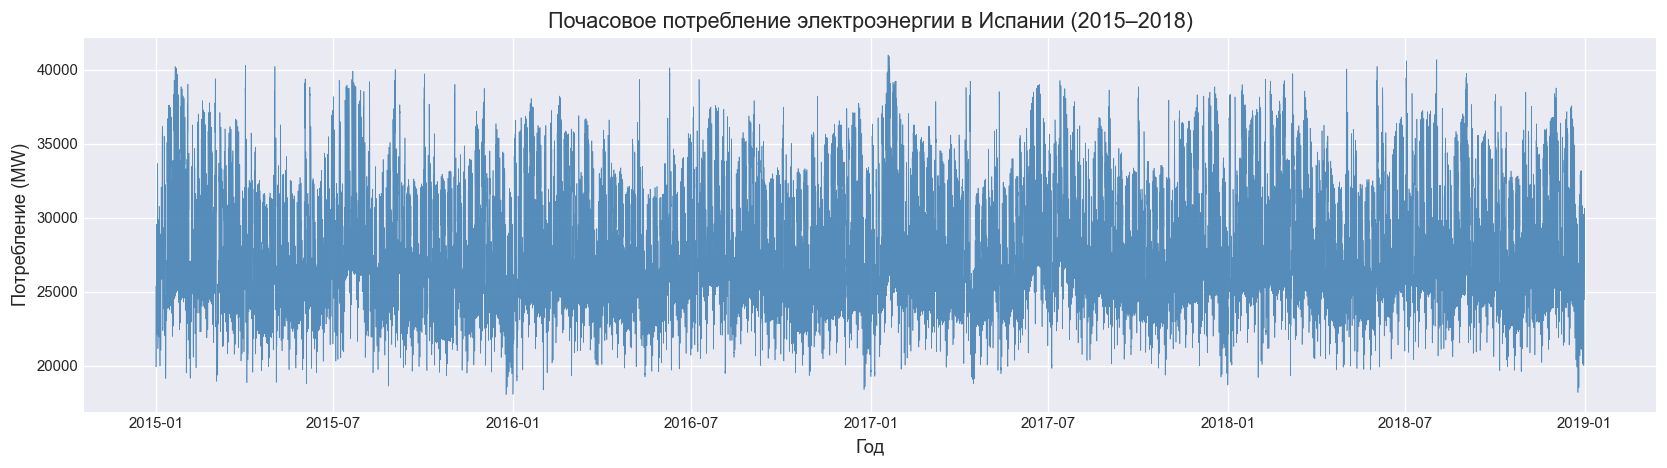

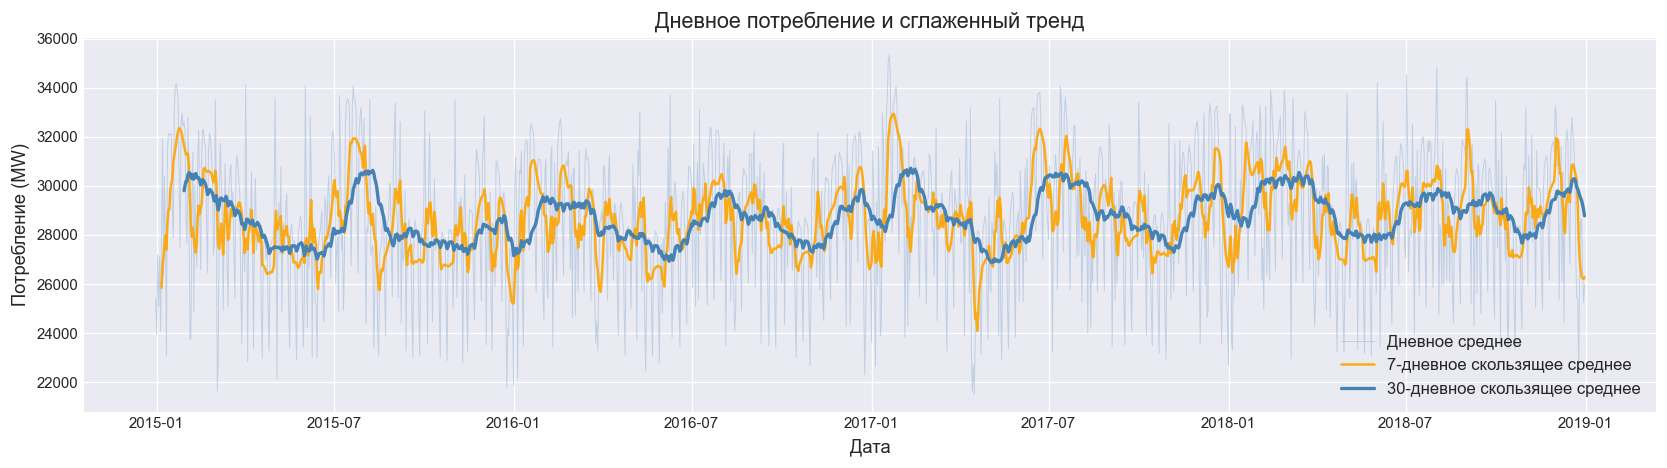

In [5]:
plt.figure(figsize=(14, 4))
plt.plot(df['time'], df['total load actual'], linewidth=0.4, color='steelblue', alpha=0.9)
plt.title('Почасовое потребление электроэнергии в Испании (2015–2018)')
plt.xlabel('Год')
plt.ylabel('Потребление (MW)')
plt.tight_layout()
plt.show()

df_daily = df.set_index('time').resample('D')['total load actual'].mean()
plt.figure(figsize=(14, 4))
plt.plot(df_daily.index, df_daily.values, linewidth=0.6,
         color='lightsteelblue', alpha=0.7, label='Дневное среднее')
plt.plot(df_daily.index, df_daily.rolling(7).mean(), linewidth=1.5,
         color='orange', alpha=0.9, label='7-дневное скользящее среднее')
plt.plot(df_daily.index, df_daily.rolling(30).mean(), linewidth=2,
         color='steelblue', label='30-дневное скользящее среднее')
plt.title('Дневное потребление и сглаженный тренд')
plt.xlabel('Дата')
plt.ylabel('Потребление (MW)')
plt.legend()
plt.tight_layout()
plt.show()

### 3.3 Суточная, недельная и годовая сезонность

Проверяем гипотезу: **потребление зависит от часа, дня недели и месяца**. Ожидаем пики утром и вечером, провал ночью; выходные должны отличаться от рабочих.

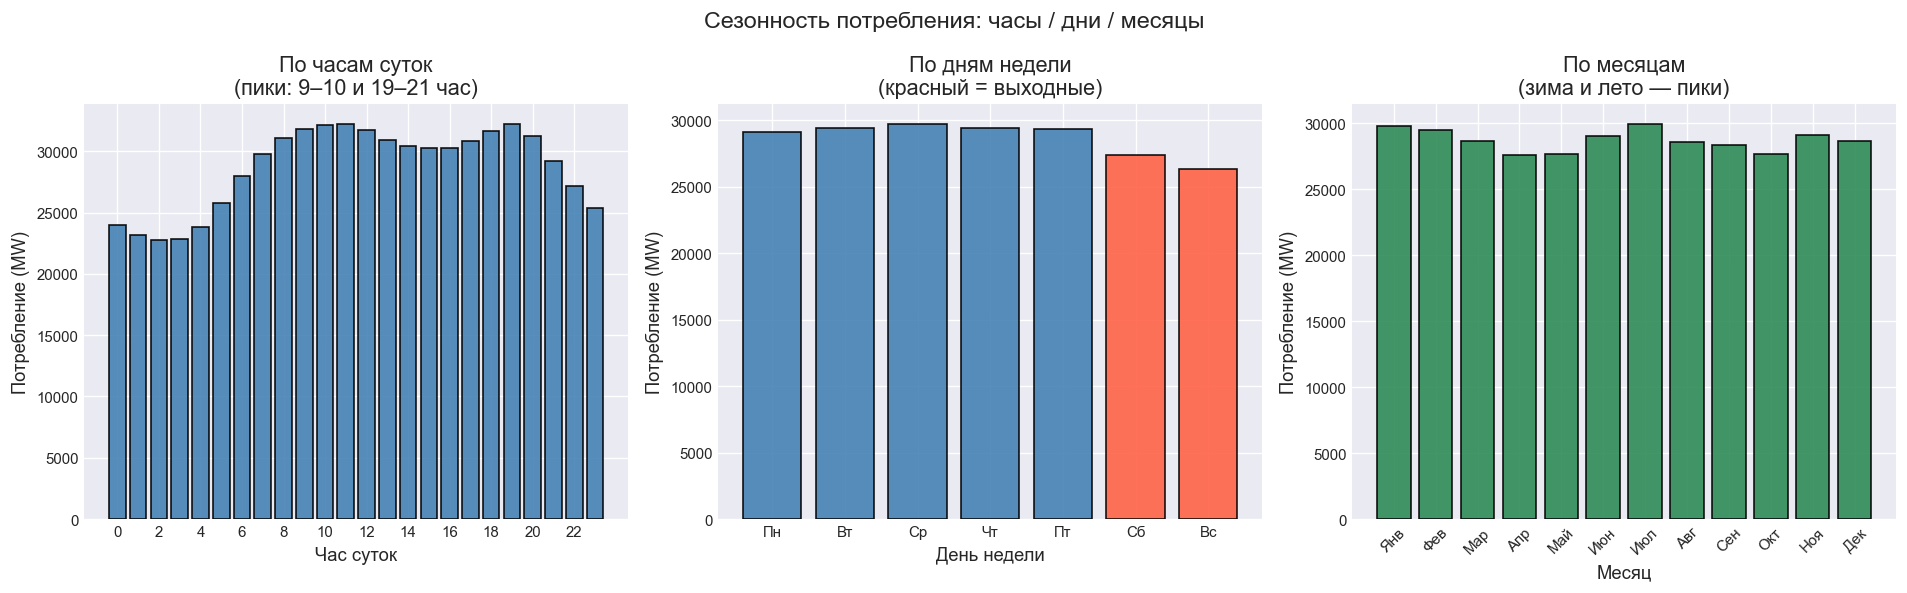

In [6]:
month_names = ['Янв','Фев','Мар','Апр','Май','Июн',
               'Июл','Авг','Сен','Окт','Ноя','Дек']
day_names   = ['Пн','Вт','Ср','Чт','Пт','Сб','Вс']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

hourly = df.groupby('hour')['total load actual'].mean()
axes[0].bar(hourly.index, hourly.values, color='steelblue', edgecolor='black', alpha=0.9)
axes[0].set_title('По часам суток\n(пики: 9–10 и 19–21 час)')
axes[0].set_xlabel('Час суток')
axes[0].set_ylabel('Потребление (MW)')
axes[0].set_xticks(range(0, 24, 2))

weekly = df.groupby('day_of_week')['total load actual'].mean()
colors_w = ['steelblue']*5 + ['tomato']*2
axes[1].bar(range(7), weekly.values, color=colors_w, edgecolor='black', alpha=0.9)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_names)
axes[1].set_title('По дням недели\n(красный = выходные)')
axes[1].set_xlabel('День недели')
axes[1].set_ylabel('Потребление (MW)')

monthly_c = df.groupby('month')['total load actual'].mean()
axes[2].bar(range(1, 13), monthly_c.values, color='seagreen', edgecolor='black', alpha=0.9)
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(month_names, rotation=45)
axes[2].set_title('По месяцам\n(зима и лето — пики)')
axes[2].set_xlabel('Месяц')
axes[2].set_ylabel('Потребление (MW)')

plt.suptitle('Сезонность потребления: часы / дни / месяцы', fontsize=14)
plt.tight_layout()
plt.show()

### 3.4 Сезонность возобновляемой генерации

Солнечная генерация максимальна летом, ветровая — зимой. Это важно для планирования резервных мощностей.

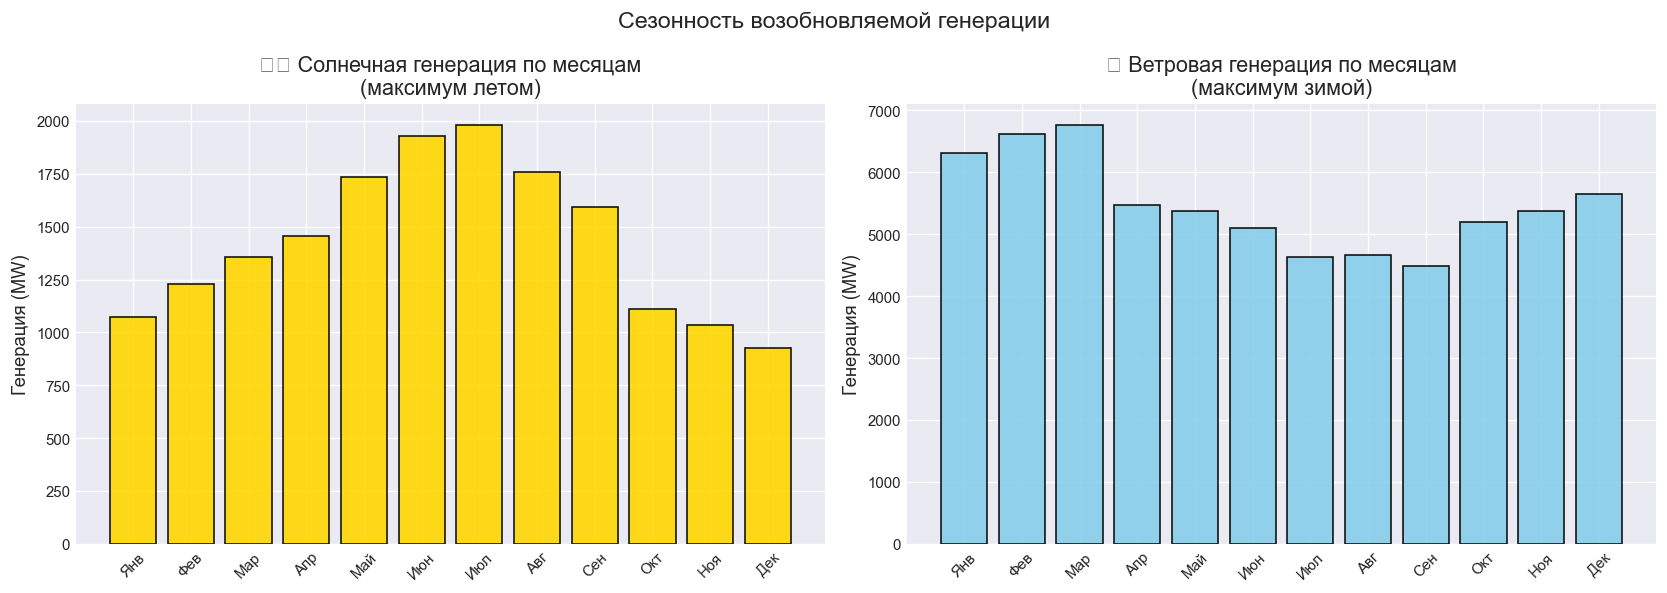

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
monthly_gen = df.groupby('month')[['generation solar','generation wind onshore']].mean()

axes[0].bar(range(1, 13), monthly_gen['generation solar'],
            color='gold', edgecolor='black', alpha=0.9)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names, rotation=45)
axes[0].set_title('☀️ Солнечная генерация по месяцам\n(максимум летом)')
axes[0].set_ylabel('Генерация (MW)')

axes[1].bar(range(1, 13), monthly_gen['generation wind onshore'],
            color='skyblue', edgecolor='black', alpha=0.9)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names, rotation=45)
axes[1].set_title('💨 Ветровая генерация по месяцам\n(максимум зимой)')
axes[1].set_ylabel('Генерация (MW)')

plt.suptitle('Сезонность возобновляемой генерации', fontsize=14)
plt.tight_layout()
plt.show()

### 3.5 Условные распределения (boxplot)

**Boxplot:** коробка = [Q1, Q3], линия = медиана, усы = нормальный диапазон, точки = выбросы.

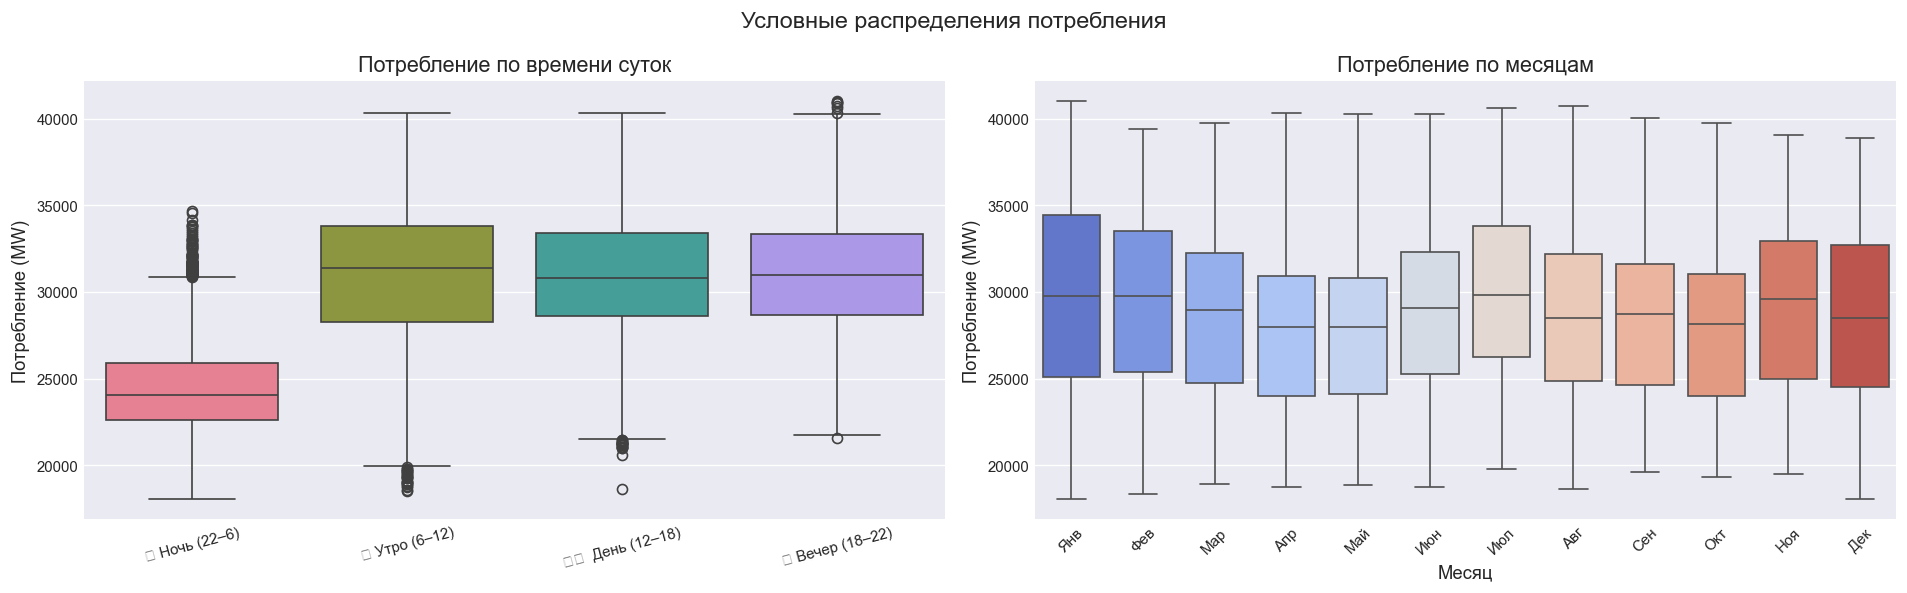

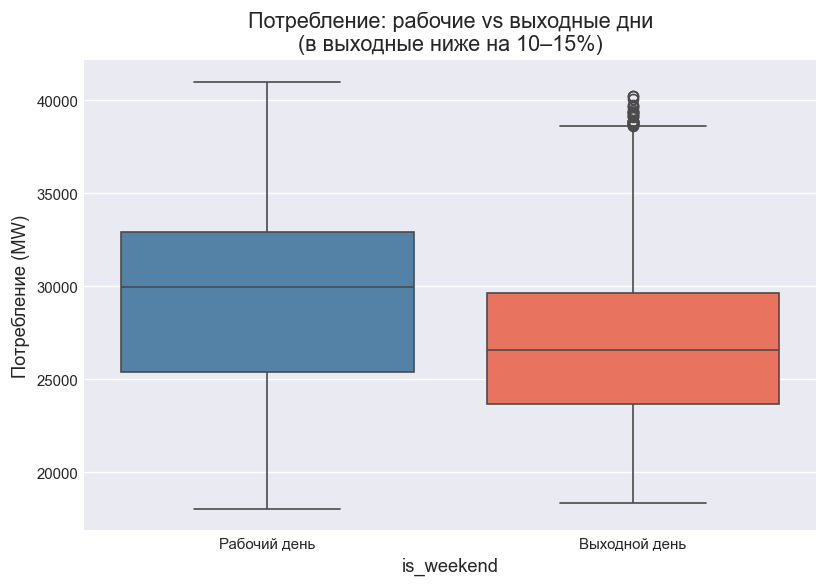

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df['time_of_day'] = df['hour'].map(
    lambda h: '🌙 Ночь (22–6)'   if (h < 6 or h >= 22)
    else      '🌅 Утро (6–12)'   if h < 12
    else      '☀️  День (12–18)' if h < 18
    else      '🌆 Вечер (18–22)'
)
order_tod = ['🌙 Ночь (22–6)','🌅 Утро (6–12)','☀️  День (12–18)','🌆 Вечер (18–22)']
sns.boxplot(data=df, x='time_of_day', y='total load actual',
            order=order_tod, palette='husl', ax=axes[0])
axes[0].set_title('Потребление по времени суток')
axes[0].set_xlabel('')
axes[0].set_ylabel('Потребление (MW)')
axes[0].tick_params(axis='x', rotation=15)

sns.boxplot(data=df, x='month', y='total load actual',
            palette='coolwarm', ax=axes[1])
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(month_names, rotation=45)
axes[1].set_title('Потребление по месяцам')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Потребление (MW)')

plt.suptitle('Условные распределения потребления', fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='is_weekend', y='total load actual',
            palette=['steelblue','tomato'])
plt.xticks([0, 1], ['Рабочий день', 'Выходной день'])
plt.title('Потребление: рабочие vs выходные дни\n(в выходные ниже на 10–15%)')
plt.ylabel('Потребление (MW)')
plt.tight_layout()
plt.show()

### 3.6 Матрица корреляций

**Корреляция** — мера линейной зависимости (от −1 до +1). Тёплые цвета (красный) = положительная, холодные (синий) = отрицательная.

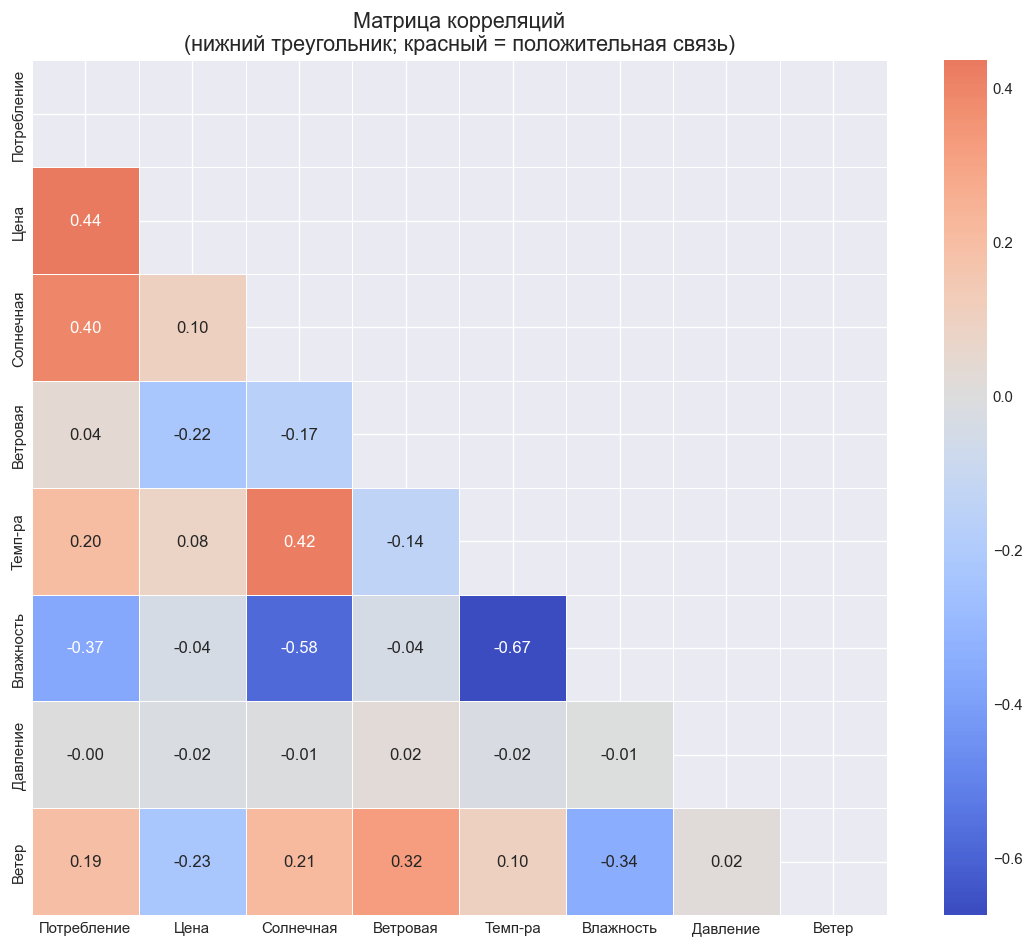

In [9]:
corr_cols   = ['total load actual','price actual','generation solar',
               'generation wind onshore','temp_c','humidity','pressure','wind_speed']
corr_labels = ['Потребление','Цена','Солнечная','Ветровая',
               'Темп-ра','Влажность','Давление','Ветер']

corr_matrix = df[corr_cols].corr()
corr_matrix.index   = corr_labels
corr_matrix.columns = corr_labels

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, mask=mask, annot_kws={'size': 10})
plt.title('Матрица корреляций\n(нижний треугольник; красный = положительная связь)',
          fontsize=13)
plt.tight_layout()
plt.show()

### 3.7 Диаграммы рассеяния

Каждая точка — один час наблюдений (показываем 5 000 из 35 000 для скорости отрисовки).

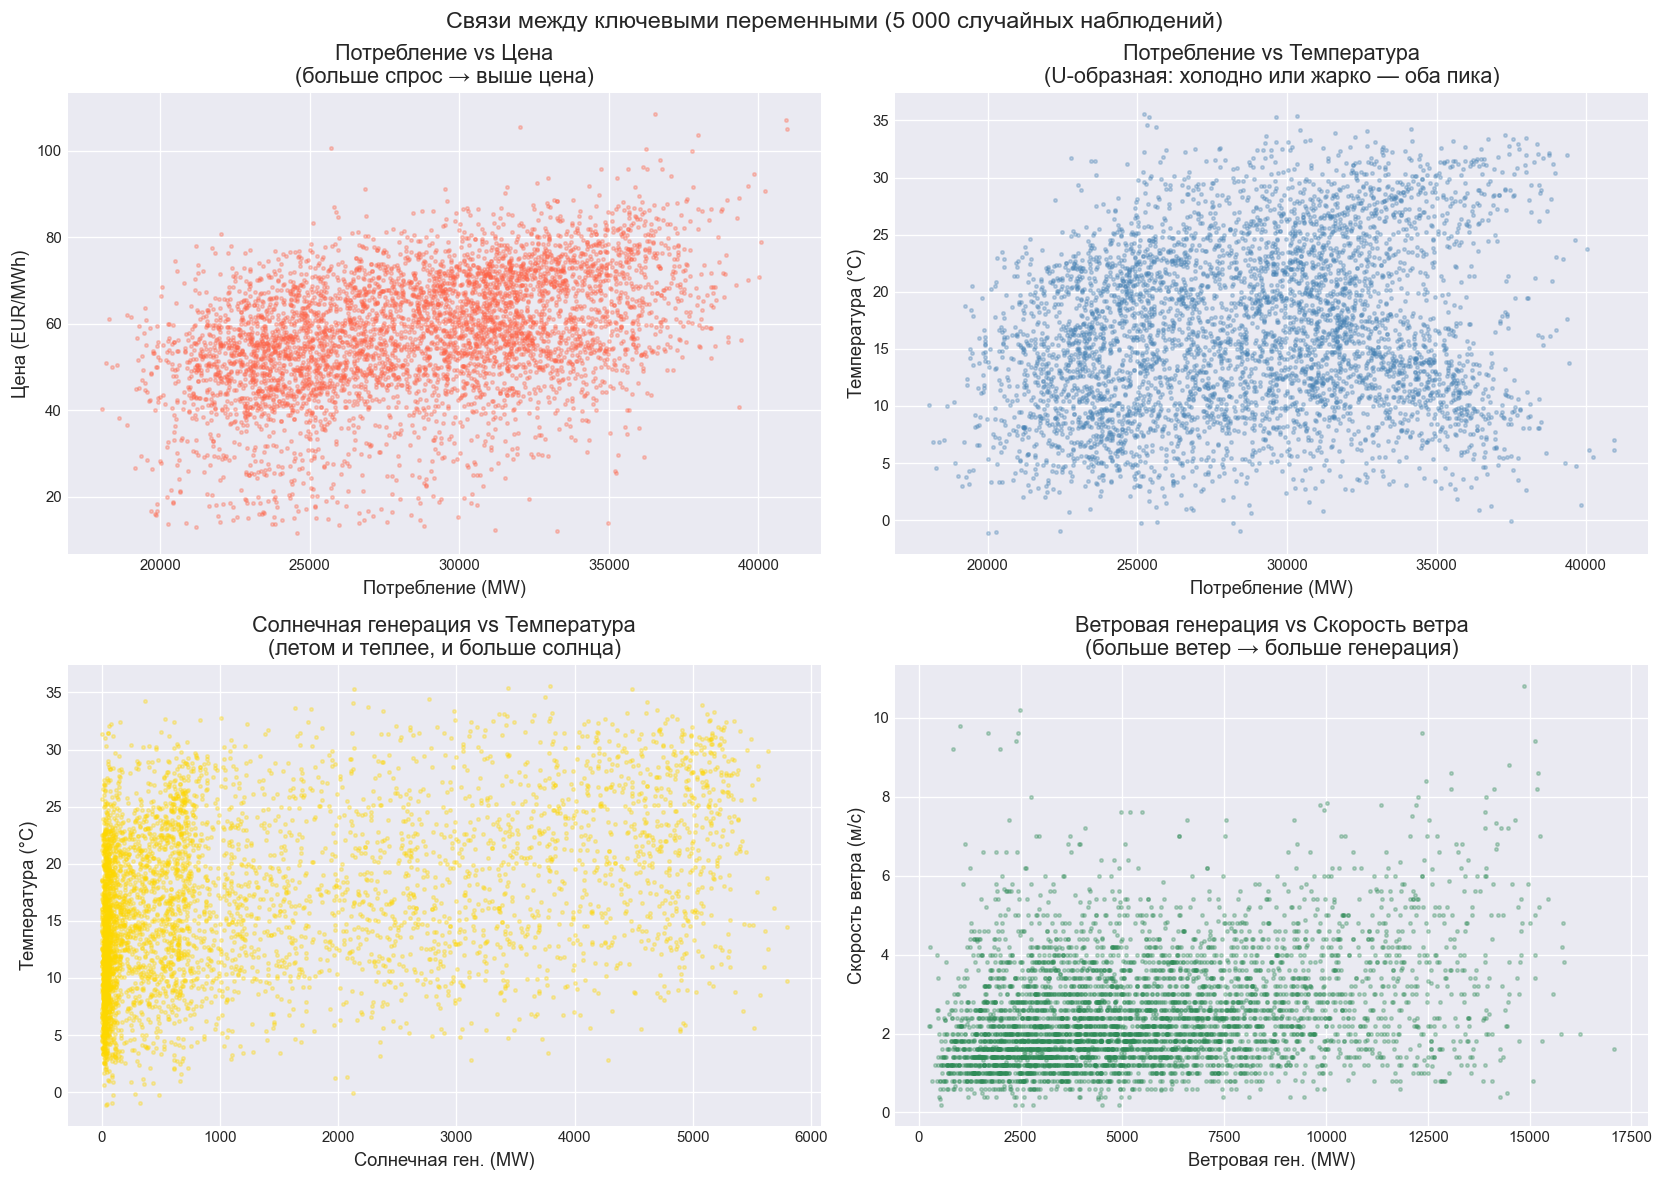

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
scatter_pairs = [
    ('total load actual', 'price actual',
     'Потребление (MW)', 'Цена (EUR/MWh)', 'tomato'),
    ('total load actual', 'temp_c',
     'Потребление (MW)', 'Температура (°C)', 'steelblue'),
    ('generation solar', 'temp_c',
     'Солнечная ген. (MW)', 'Температура (°C)', 'gold'),
    ('generation wind onshore', 'wind_speed',
     'Ветровая ген. (MW)', 'Скорость ветра (м/с)', 'seagreen'),
]
titles = [
    'Потребление vs Цена\n(больше спрос → выше цена)',
    'Потребление vs Температура\n(U-образная: холодно или жарко — оба пика)',
    'Солнечная генерация vs Температура\n(летом и теплее, и больше солнца)',
    'Ветровая генерация vs Скорость ветра\n(больше ветер → больше генерация)',
]
np.random.seed(42)
sample_idx = np.random.choice(len(df), 5000, replace=False)
for ax, (cx, cy, xl, yl, color), title in zip(axes.flatten(), scatter_pairs, titles):
    ax.scatter(df[cx].iloc[sample_idx], df[cy].iloc[sample_idx],
               s=4, alpha=0.3, color=color)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(title)
plt.suptitle('Связи между ключевыми переменными (5 000 случайных наблюдений)', fontsize=14)
plt.tight_layout()
plt.show()

## IV. Модели регрессии и классификации

### 4.1 Множественная линейная регрессия

**Задача:** по 10 признакам предсказать фактическое потребление (MW).

**Метрики:**
- **R²** — доля объяснённой дисперсии (1 = идеально, 0 = бесполезно)
- **MAE** — средняя абсолютная ошибка в MW
- **RMSE** — среднеквадратичная ошибка

=== Линейная регрессия ===
R²   = 0.3391  (объясняет 33.9% вариативности)
MAE  = 3012 MW  (средняя ошибка)
RMSE = 3711 MW


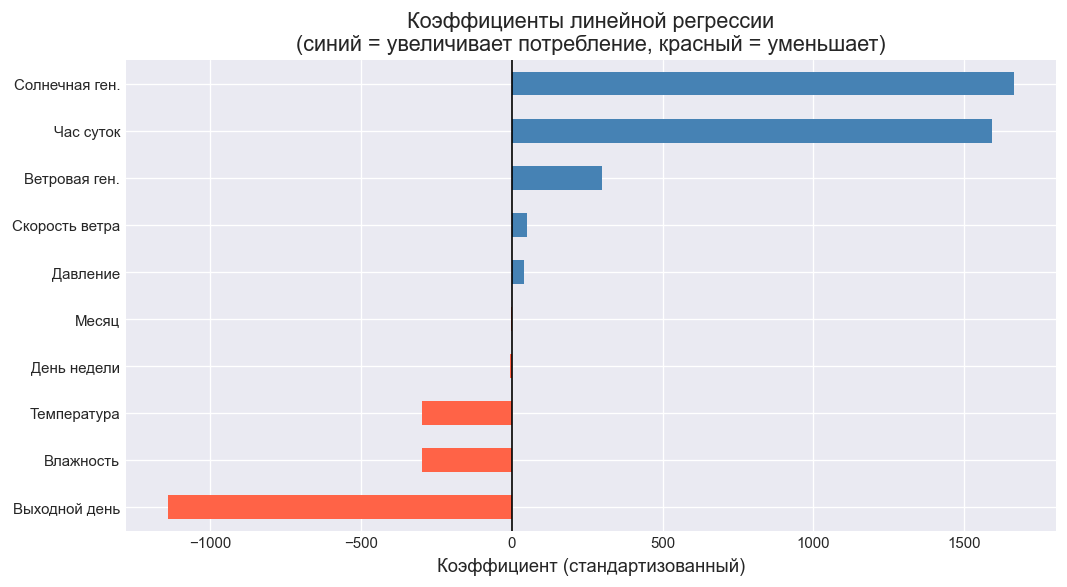

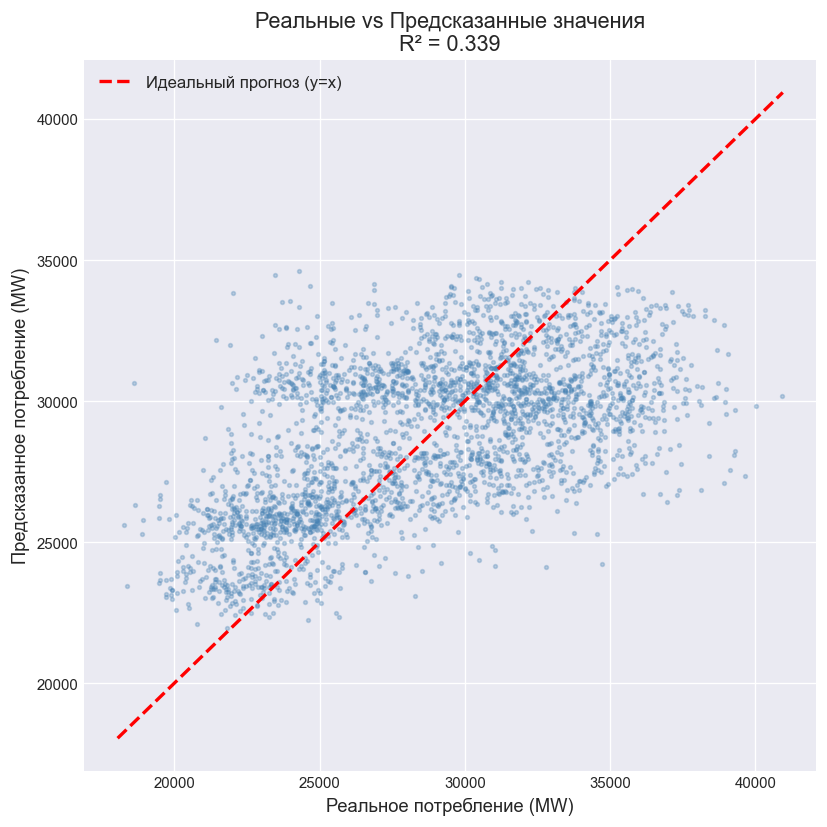

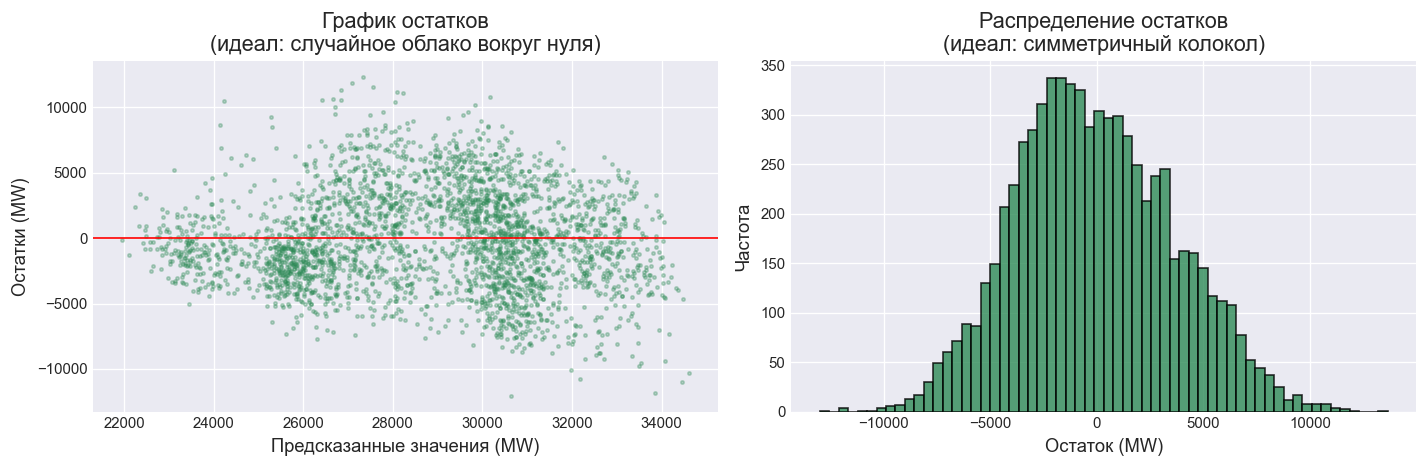

In [11]:
feat_reg = ['hour','day_of_week','month','is_weekend',
            'temp_c','humidity','pressure','wind_speed',
            'generation solar','generation wind onshore']

X = df[feat_reg].values
y = df['total load actual'].values

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
sc_reg = StandardScaler()
Xtr_s  = sc_reg.fit_transform(Xtr)
Xte_s  = sc_reg.transform(Xte)

lr   = LinearRegression().fit(Xtr_s, ytr)
yhat = lr.predict(Xte_s)

r2   = r2_score(yte, yhat)
mae  = mean_absolute_error(yte, yhat)
rmse = np.sqrt(mean_squared_error(yte, yhat))

print('=== Линейная регрессия ===')
print(f'R²   = {r2:.4f}  (объясняет {r2*100:.1f}% вариативности)')
print(f'MAE  = {mae:.0f} MW  (средняя ошибка)')
print(f'RMSE = {rmse:.0f} MW')

feat_labels = ['Час суток','День недели','Месяц','Выходной день',
               'Температура','Влажность','Давление','Скорость ветра',
               'Солнечная ген.','Ветровая ген.']
fi = pd.Series(lr.coef_, index=feat_labels).sort_values(ascending=True)
colors_fi = ['tomato' if v < 0 else 'steelblue' for v in fi.values]

plt.figure(figsize=(9, 5))
fi.plot(kind='barh', color=colors_fi)
plt.axvline(0, color='black', linewidth=1)
plt.title('Коэффициенты линейной регрессии\n'
          '(синий = увеличивает потребление, красный = уменьшает)')
plt.xlabel('Коэффициент (стандартизованный)')
plt.tight_layout()
plt.show()

np.random.seed(42)
sample = np.random.choice(len(yte), 3000, replace=False)
plt.figure(figsize=(7, 7))
plt.scatter(yte[sample], yhat[sample], s=5, alpha=0.3, color='steelblue')
mn, mx = yte.min(), yte.max()
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Идеальный прогноз (y=x)')
plt.xlabel('Реальное потребление (MW)')
plt.ylabel('Предсказанное потребление (MW)')
plt.title(f'Реальные vs Предсказанные значения\nR² = {r2:.3f}')
plt.legend()
plt.tight_layout()
plt.show()

residuals = yte - yhat
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(yhat[sample], residuals[sample], s=4, alpha=0.3, color='seagreen')
axes[0].axhline(0, color='red', linewidth=1)
axes[0].set_xlabel('Предсказанные значения (MW)')
axes[0].set_ylabel('Остатки (MW)')
axes[0].set_title('График остатков\n(идеал: случайное облако вокруг нуля)')
axes[1].hist(residuals, bins=60, color='seagreen', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Остаток (MW)')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение остатков\n(идеал: симметричный колокол)')
plt.tight_layout()
plt.show()

### 4.2 Логистическая регрессия (классификация пиков нагрузки)

**Задача:** класс 1 = потребление выше медианы («высокий спрос»), класс 0 = ниже.

**Метрики:** Accuracy, Precision, Recall, F1-score, матрица ошибок.

Порог (медиана): 28901 MW
Класс 0: 17551  |  Класс 1: 17513

Accuracy = 0.7442 (74.4% правильно)
               precision    recall  f1-score   support

 Низкий спрос       0.76      0.72      0.74      3510
Высокий спрос       0.73      0.77      0.75      3503

     accuracy                           0.74      7013
    macro avg       0.75      0.74      0.74      7013
 weighted avg       0.75      0.74      0.74      7013



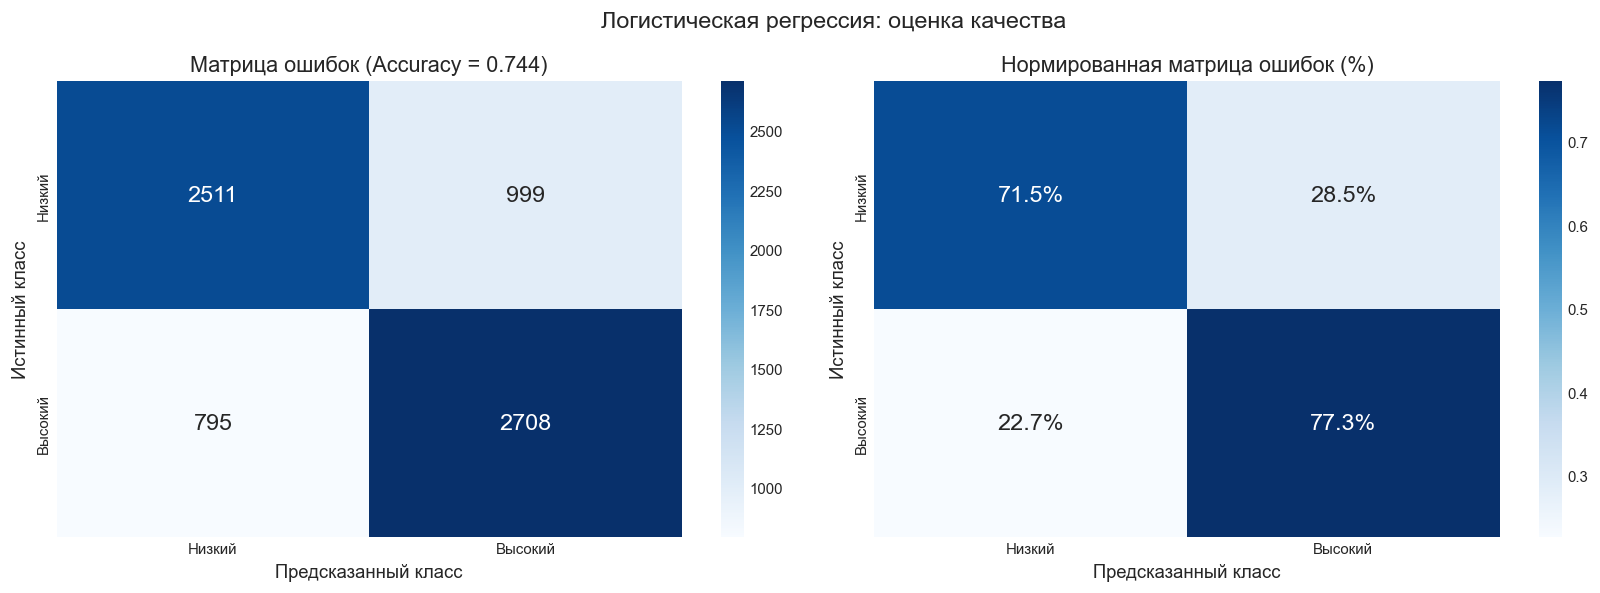

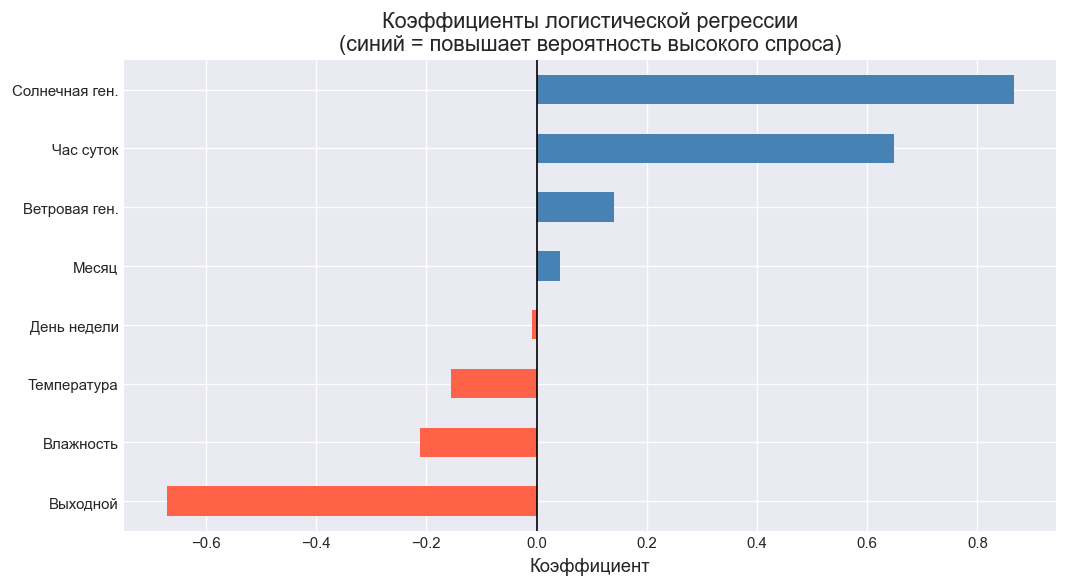

In [12]:
thr = df['total load actual'].median()
df['high_demand'] = (df['total load actual'] > thr).astype(int)
print(f'Порог (медиана): {thr:.0f} MW')
print(f'Класс 0: {(df.high_demand==0).sum()}  |  Класс 1: {(df.high_demand==1).sum()}')

feat_cl = ['hour','day_of_week','month','is_weekend','temp_c','humidity',
           'generation solar','generation wind onshore']
Xc = df[feat_cl].values
yc = df['high_demand'].values

Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(
    Xc, yc, test_size=0.2, random_state=42, stratify=yc)
sc_cl   = StandardScaler()
Xtr_c_s = sc_cl.fit_transform(Xtr_c)
Xte_c_s = sc_cl.transform(Xte_c)

logr   = LogisticRegression(max_iter=1000).fit(Xtr_c_s, ytr_c)
yc_hat = logr.predict(Xte_c_s)
acc    = accuracy_score(yte_c, yc_hat)

print(f'\nAccuracy = {acc:.4f} ({acc*100:.1f}% правильно)')
print(classification_report(yte_c, yc_hat,
      target_names=['Низкий спрос','Высокий спрос']))

cm = confusion_matrix(yte_c, yc_hat)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Низкий','Высокий'],
            yticklabels=['Низкий','Высокий'],
            ax=axes[0], annot_kws={'size': 14})
axes[0].set_xlabel('Предсказанный класс')
axes[0].set_ylabel('Истинный класс')
axes[0].set_title(f'Матрица ошибок (Accuracy = {acc:.3f})')

cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=['Низкий','Высокий'],
            yticklabels=['Низкий','Высокий'],
            ax=axes[1], annot_kws={'size': 14})
axes[1].set_xlabel('Предсказанный класс')
axes[1].set_ylabel('Истинный класс')
axes[1].set_title('Нормированная матрица ошибок (%)')
plt.suptitle('Логистическая регрессия: оценка качества', fontsize=14)
plt.tight_layout()
plt.show()

feat_cl_labels = ['Час суток','День недели','Месяц','Выходной',
                  'Температура','Влажность','Солнечная ген.','Ветровая ген.']
fi_log = pd.Series(logr.coef_[0], index=feat_cl_labels).sort_values(ascending=True)
colors_log = ['tomato' if v < 0 else 'steelblue' for v in fi_log.values]
plt.figure(figsize=(9, 5))
fi_log.plot(kind='barh', color=colors_log)
plt.axvline(0, color='black', linewidth=1)
plt.title('Коэффициенты логистической регрессии\n'
          '(синий = повышает вероятность высокого спроса)')
plt.xlabel('Коэффициент')
plt.tight_layout()
plt.show()

## V. Снижение размерности – PCA

**PCA** заменяет коррелированные признаки на меньшее число **независимых компонент**.

Признаки генерации (газ, уголь, ветер, солнце) сильно коррелируют — это **мультиколлинеарность**, которая ухудшает линейную регрессию. PCA её устраняет.

**Scree plot** показывает, сколько компонент нужно, чтобы объяснить ≥85% дисперсии.

Доли объяснённой дисперсии:
  PC 1: 0.248 (24.8%)  накопл.: 0.248  ████████████████████████
  PC 2: 0.222 (22.2%)  накопл.: 0.470  ██████████████████████
  PC 3: 0.118 (11.8%)  накопл.: 0.588  ███████████
  PC 4: 0.100 (10.0%)  накопл.: 0.687  █████████
  PC 5: 0.089 (8.9%)  накопл.: 0.776  ████████
  PC 6: 0.072 (7.2%)  накопл.: 0.848  ███████
  PC 7: 0.056 (5.6%)  накопл.: 0.904  █████
  PC 8: 0.046 (4.6%)  накопл.: 0.949  ████
  PC 9: 0.027 (2.7%)  накопл.: 0.977  ██
  PC10: 0.023 (2.3%)  накопл.: 1.000  ██


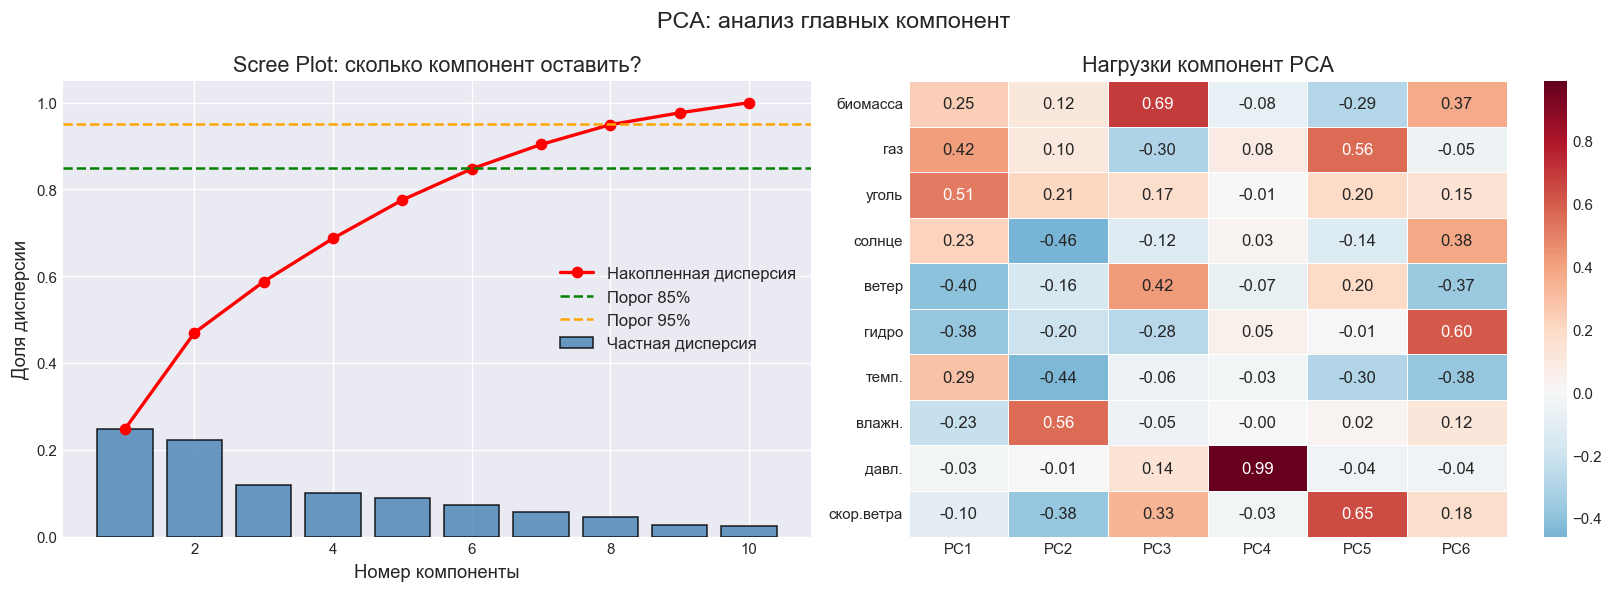

Базовая регрессия:  R²=0.3391,  MAE=3012 MW
Регрессия + PCA:    R²=0.4939,  MAE=2571 MW


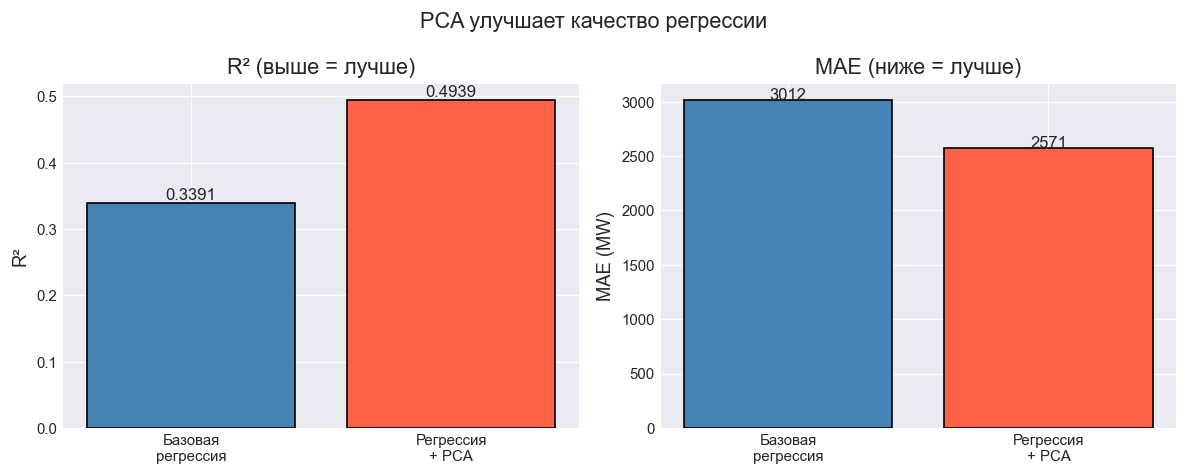

In [13]:
pca_feats = ['generation biomass','generation fossil gas',
             'generation fossil hard coal','generation solar',
             'generation wind onshore',
             'generation hydro run-of-river and poundage',
             'temp_c','humidity','pressure','wind_speed']

Xp   = df[pca_feats].values
sc_p = StandardScaler()
Xp_s = sc_p.fit_transform(Xp)

pca_full   = PCA().fit(Xp_s)
var_ratios = pca_full.explained_variance_ratio_
cum_var    = np.cumsum(var_ratios)

print('Доли объяснённой дисперсии:')
for i, (v, c) in enumerate(zip(var_ratios, cum_var), 1):
    bar = '█' * int(v * 100)
    print(f'  PC{i:2d}: {v:.3f} ({v*100:.1f}%)  накопл.: {c:.3f}  {bar}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
n_comp = len(var_ratios)
axes[0].bar(range(1, n_comp+1), var_ratios,
            color='steelblue', edgecolor='black', alpha=0.8, label='Частная дисперсия')
axes[0].plot(range(1, n_comp+1), cum_var,
             marker='o', color='red', linewidth=2, label='Накопленная дисперсия')
axes[0].axhline(0.85, color='green', linestyle='--', linewidth=1.5, label='Порог 85%')
axes[0].axhline(0.95, color='orange', linestyle='--', linewidth=1.5, label='Порог 95%')
axes[0].set_xlabel('Номер компоненты')
axes[0].set_ylabel('Доля дисперсии')
axes[0].set_title('Scree Plot: сколько компонент оставить?')
axes[0].legend()

pca6 = PCA(n_components=6).fit(Xp_s)
pca_labels = ['биомасса','газ','уголь','солнце','ветер','гидро',
              'темп.','влажн.','давл.','скор.ветра']
comp_df = pd.DataFrame(pca6.components_.T, index=pca_labels,
                       columns=[f'PC{i+1}' for i in range(6)])
sns.heatmap(comp_df, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=axes[1])
axes[1].set_title('Нагрузки компонент PCA')
plt.suptitle('PCA: анализ главных компонент', fontsize=14)
plt.tight_layout()
plt.show()

Z = pca6.transform(Xp_s)
T = df[['hour','day_of_week','month','is_weekend']].values
X_pca_reg = np.hstack([Z, T])

Xtr_p, Xte_p, ytr_p, yte_p = train_test_split(
    X_pca_reg, df['total load actual'].values, test_size=0.2, random_state=42)
lr_p    = LinearRegression().fit(Xtr_p, ytr_p)
yhat_p  = lr_p.predict(Xte_p)
r2_pca  = r2_score(yte_p, yhat_p)
mae_pca = mean_absolute_error(yte_p, yhat_p)

print(f'Базовая регрессия:  R²={r2:.4f},  MAE={mae:.0f} MW')
print(f'Регрессия + PCA:    R²={r2_pca:.4f},  MAE={mae_pca:.0f} MW')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
models = ['Базовая\nрегрессия', 'Регрессия\n+ PCA']
axes[0].bar(models, [r2, r2_pca], color=['steelblue','tomato'], edgecolor='black')
axes[0].set_title('R² (выше = лучше)')
axes[0].set_ylabel('R²')
for i, v in enumerate([r2, r2_pca]):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center')
axes[1].bar(models, [mae, mae_pca], color=['steelblue','tomato'], edgecolor='black')
axes[1].set_title('MAE (ниже = лучше)')
axes[1].set_ylabel('MAE (MW)')
for i, v in enumerate([mae, mae_pca]):
    axes[1].text(i, v + 10, f'{v:.0f}', ha='center')
plt.suptitle('PCA улучшает качество регрессии', fontsize=13)
plt.tight_layout()
plt.show()

## VI. Анализ временных рядов – ARIMA

**ARIMA(p, d, q):** AR = авторегрессия (прошлые значения), I = дифференцирование (стационарность), MA = скользящее среднее (прошлые ошибки).

**Стационарность** проверяем тестом Дики–Фуллера (ADF): p-value < 0.05 → ряд стационарен.

**ACF/PACF** помогают выбрать параметры q и p соответственно.

Дневной ряд: 1462 точек
Период: 2014-12-31 — 2018-12-31
count     1462.0
mean     28694.9
std       2738.6
min      21493.6
25%      27149.1
50%      28664.2
75%      30810.8
max      35339.8
Name: total load actual, dtype: float64


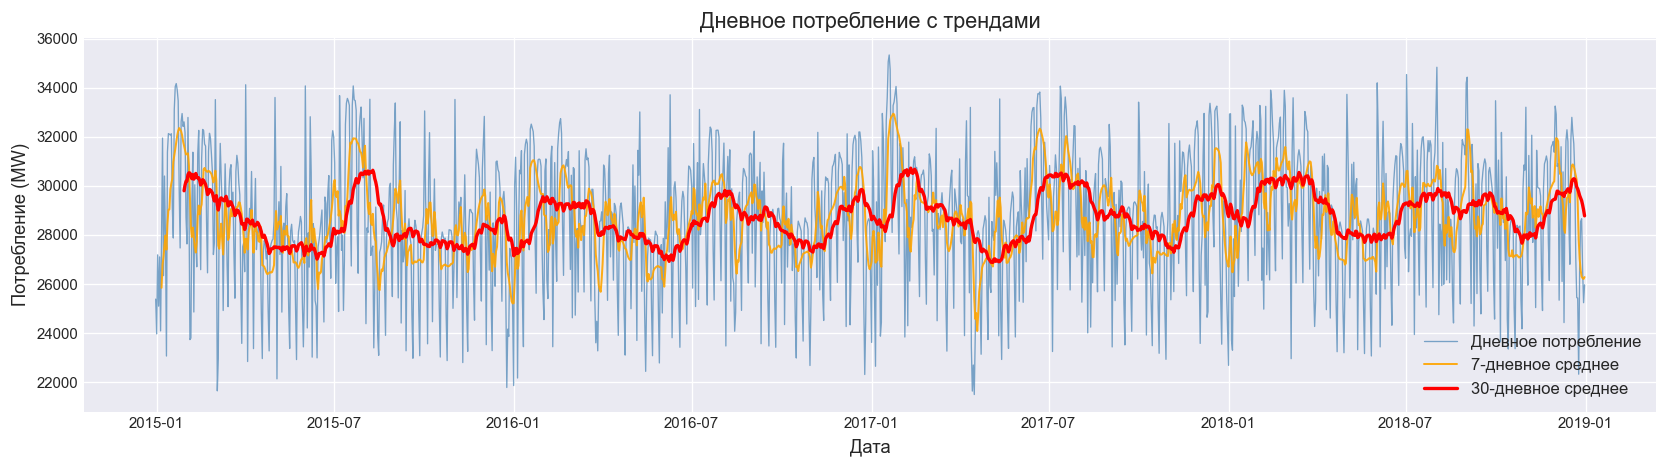


=== Тест Дики–Фуллера ===
ADF-статистика: -6.4601
p-value:        0.000000
✅ Ряд СТАЦИОНАРЕН (p < 0.05)


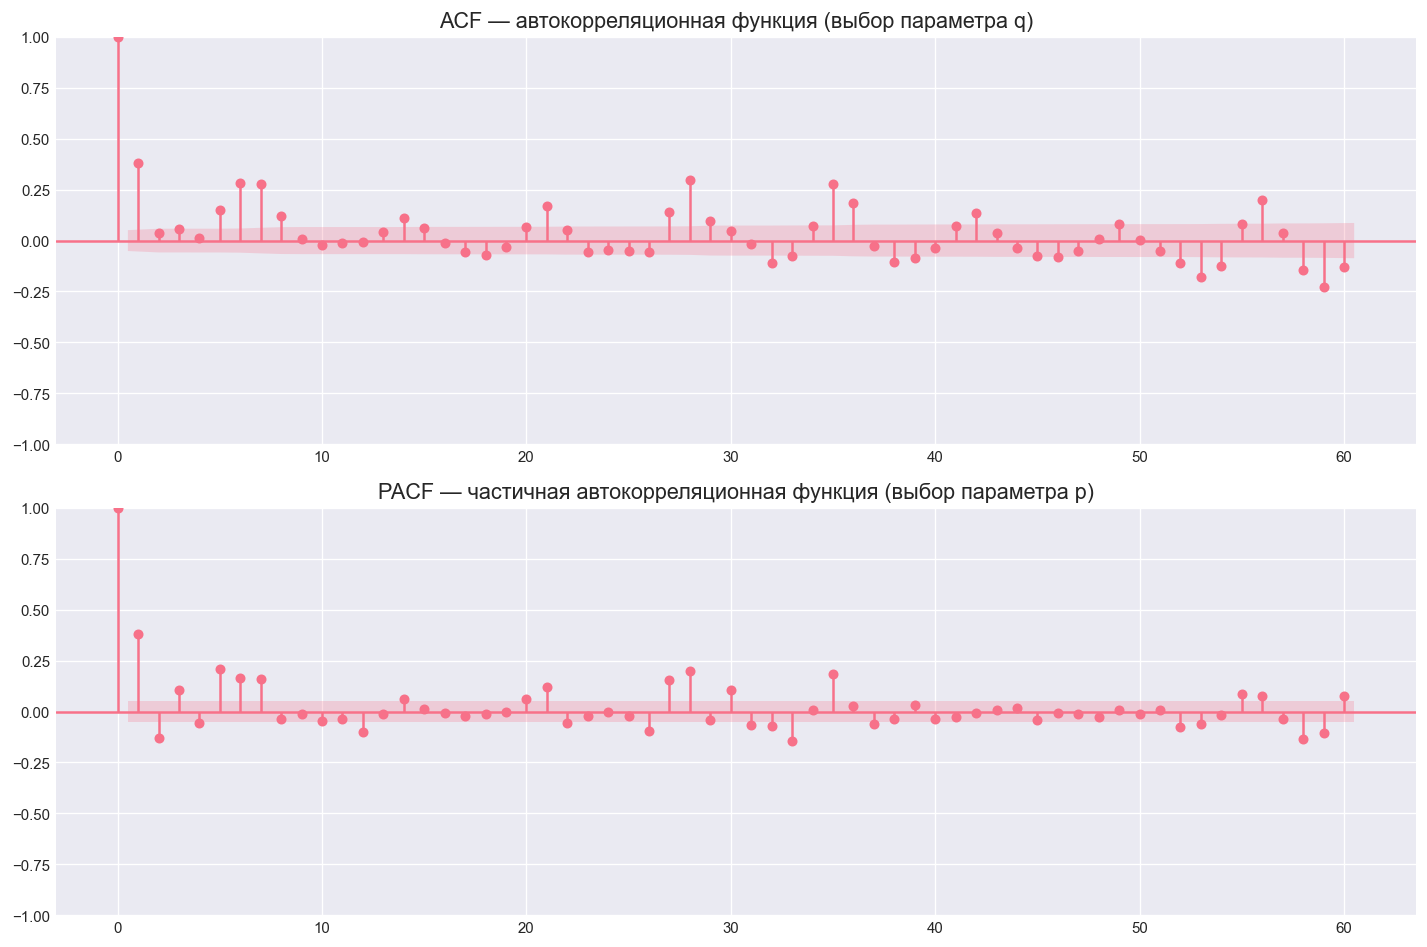

Обучение ARIMA(2,0,2)...

=== ARIMA(2, 0, 2) ===
MAPE = 7.66%  (средняя % ошибка)
MAE  = 2169 MW
RMSE = 2621 MW


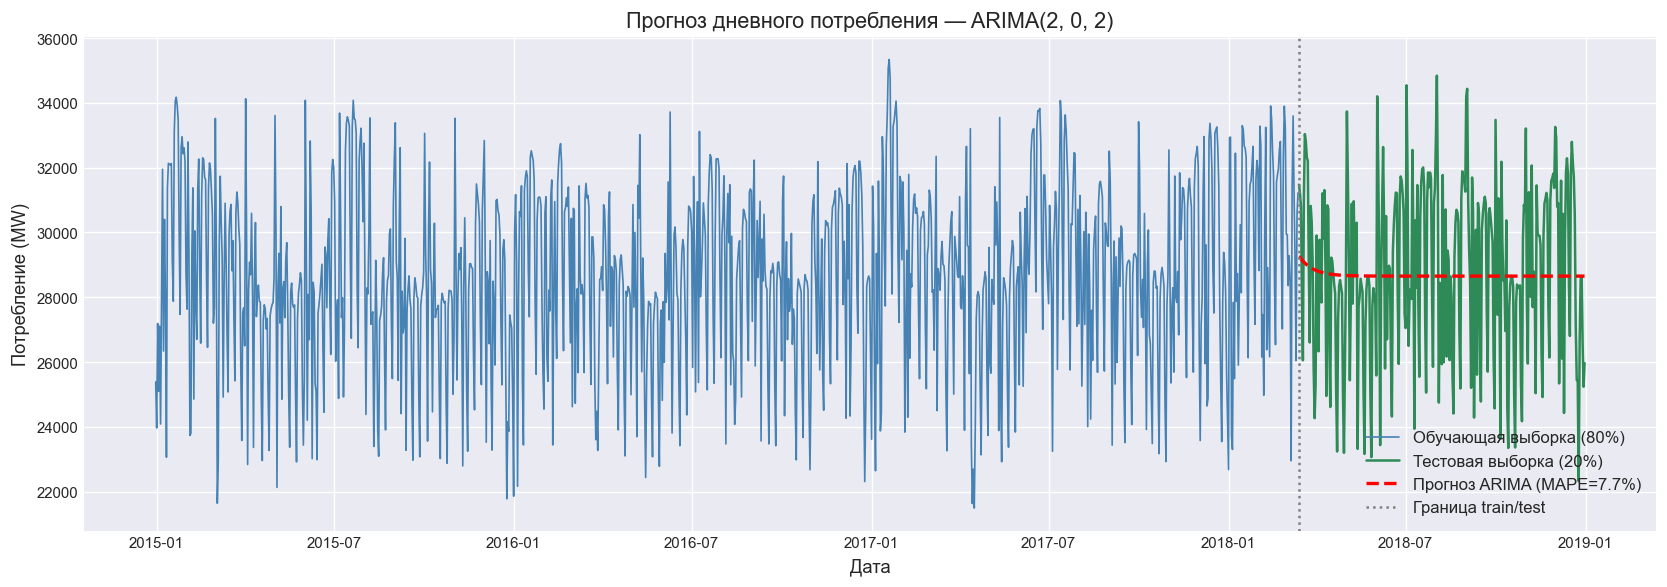

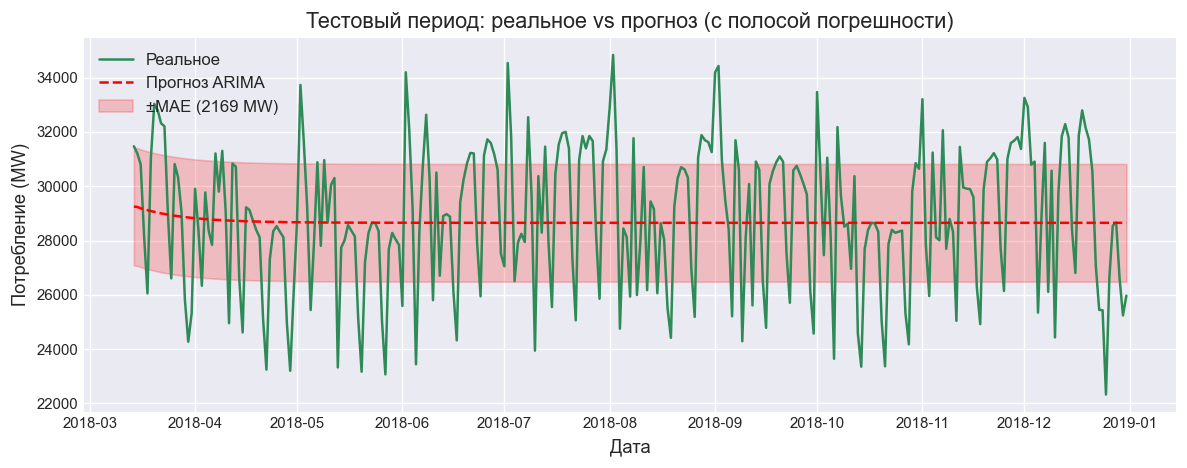

In [14]:
df_d = df.set_index('time').resample('D')['total load actual'].mean().dropna()
print(f'Дневной ряд: {len(df_d)} точек')
print(f'Период: {df_d.index[0].date()} — {df_d.index[-1].date()}')
print(df_d.describe().round(1))

plt.figure(figsize=(14, 4))
plt.plot(df_d.index, df_d.values,
         linewidth=0.8, color='steelblue', alpha=0.7, label='Дневное потребление')
plt.plot(df_d.index, df_d.rolling(7).mean(),
         linewidth=1.2, color='orange', alpha=0.9, label='7-дневное среднее')
plt.plot(df_d.index, df_d.rolling(30).mean(),
         linewidth=2, color='red', label='30-дневное среднее')
plt.title('Дневное потребление с трендами')
plt.xlabel('Дата')
plt.ylabel('Потребление (MW)')
plt.legend()
plt.tight_layout()
plt.show()

adf_result = adfuller(df_d)
print(f'\n=== Тест Дики–Фуллера ===')
print(f'ADF-статистика: {adf_result[0]:.4f}')
print(f'p-value:        {adf_result[1]:.6f}')
if adf_result[1] < 0.05:
    print('✅ Ряд СТАЦИОНАРЕН (p < 0.05)')
else:
    print('❌ Ряд НЕ стационарен — нужно дифференцирование (d=1)')

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df_d, lags=60, ax=axes[0])
axes[0].set_title('ACF — автокорреляционная функция (выбор параметра q)')
plot_pacf(df_d, lags=60, ax=axes[1])
axes[1].set_title('PACF — частичная автокорреляционная функция (выбор параметра p)')
plt.tight_layout()
plt.show()

n     = int(len(df_d) * 0.8)
train = df_d.iloc[:n]
test  = df_d.iloc[n:]

print('Обучение ARIMA(2,0,2)...')
model = ARIMA(train, order=(2, 0, 2)).fit()
fc    = model.forecast(steps=len(test))

mae_a  = mean_absolute_error(test, fc)
mape   = np.mean(np.abs((test.values - fc.values) / test.values)) * 100
rmse_a = np.sqrt(mean_squared_error(test, fc))

print(f'\n=== ARIMA(2, 0, 2) ===')
print(f'MAPE = {mape:.2f}%  (средняя % ошибка)')
print(f'MAE  = {mae_a:.0f} MW')
print(f'RMSE = {rmse_a:.0f} MW')

plt.figure(figsize=(14, 5))
plt.plot(train.index, train.values,
         color='steelblue', linewidth=1, label='Обучающая выборка (80%)')
plt.plot(test.index, test.values,
         color='seagreen', linewidth=1.5, label='Тестовая выборка (20%)')
plt.plot(test.index, fc.values,
         color='red', linewidth=2, linestyle='--',
         label=f'Прогноз ARIMA (MAPE={mape:.1f}%)')
plt.axvline(test.index[0], color='gray', linestyle=':', linewidth=1.5,
            label='Граница train/test')
plt.title('Прогноз дневного потребления — ARIMA(2, 0, 2)')
plt.xlabel('Дата')
plt.ylabel('Потребление (MW)')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(test.index, test.values,
         color='seagreen', linewidth=1.5, label='Реальное')
plt.plot(test.index, fc.values,
         color='red', linewidth=1.5, linestyle='--', label='Прогноз ARIMA')
plt.fill_between(test.index, fc.values - mae_a, fc.values + mae_a,
                 alpha=0.2, color='red', label=f'±MAE ({mae_a:.0f} MW)')
plt.title('Тестовый период: реальное vs прогноз (с полосой погрешности)')
plt.xlabel('Дата')
plt.ylabel('Потребление (MW)')
plt.legend()
plt.tight_layout()
plt.show()

## VII. Сравнение всех моделей

Сводная таблица и графики сравнения всех четырёх моделей по R², MAE и MAPE.

                        СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ                        
Модель                         Задача                   R²/Acc     MAE/MAPE
----------------------------------------------------------------------
Линейная регрессия             Прогноз потребл.         0.3391      3012 MW
Регрессия + PCA                Прогноз потребл.         0.4939      2571 MW
Логистическая регрессия        Классиф. спроса          0.7442      F1≈0.75
ARIMA(2,0,2)                   Временной прогноз             —     7.66%


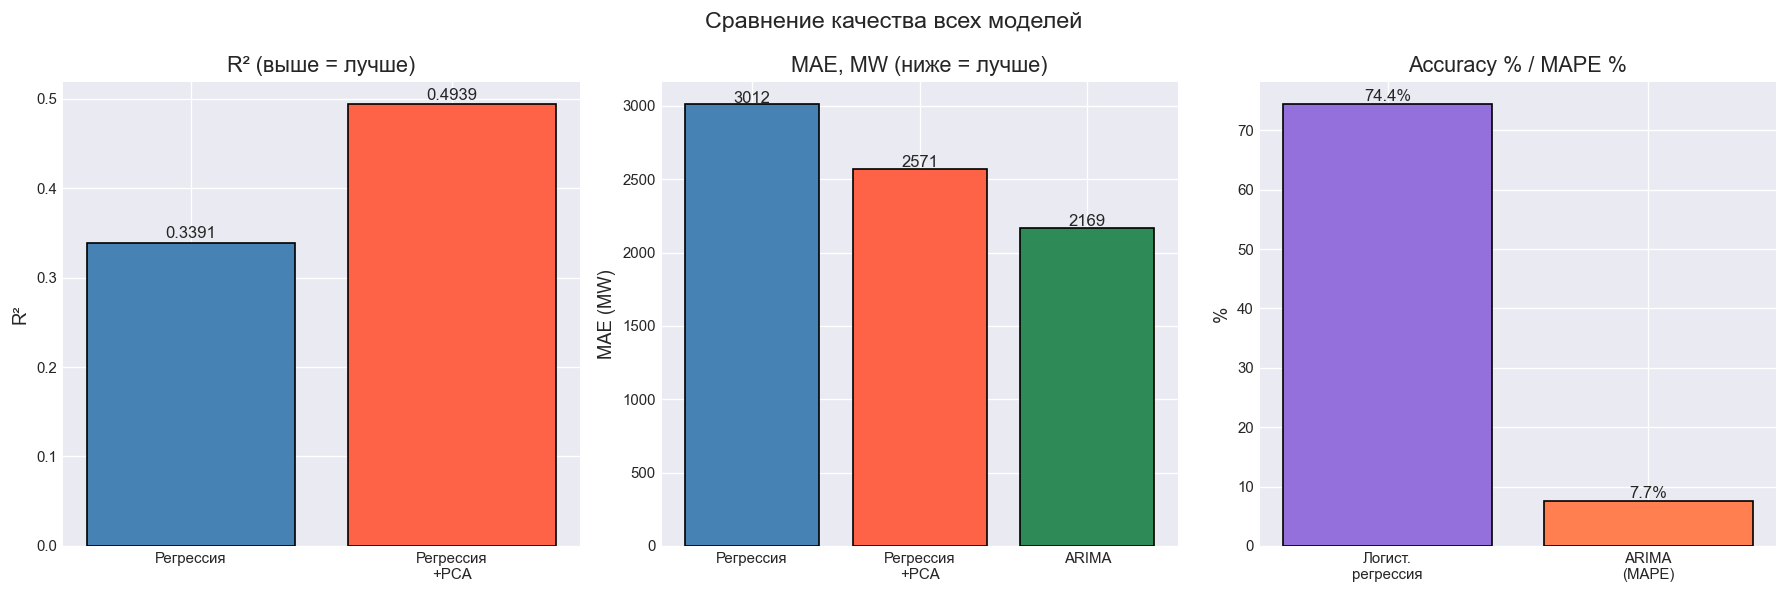

In [15]:
print('=' * 70)
print(f'{"СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ":^70}')
print('=' * 70)
print(f'{"Модель":<30} {"Задача":<22} {"R²/Acc":>8} {"MAE/MAPE":>12}')
print('-' * 70)
print(f'{"Линейная регрессия":<30} {"Прогноз потребл.":<22} {r2:>8.4f} {mae:>9.0f} MW')
print(f'{"Регрессия + PCA":<30} {"Прогноз потребл.":<22} {r2_pca:>8.4f} {mae_pca:>9.0f} MW')
print(f'{"Логистическая регрессия":<30} {"Классиф. спроса":<22} {acc:>8.4f} {"F1≈0.75":>12}')
print(f'{"ARIMA(2,0,2)":<30} {"Временной прогноз":<22} {"—":>8} {mape:>8.2f}%')
print('=' * 70)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(['Регрессия','Регрессия\n+PCA'], [r2, r2_pca],
            color=['steelblue','tomato'], edgecolor='black')
axes[0].set_title('R² (выше = лучше)')
axes[0].set_ylabel('R²')
for i, v in enumerate([r2, r2_pca]):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center')

axes[1].bar(['Регрессия','Регрессия\n+PCA','ARIMA'], [mae, mae_pca, mae_a],
            color=['steelblue','tomato','seagreen'], edgecolor='black')
axes[1].set_title('MAE, MW (ниже = лучше)')
axes[1].set_ylabel('MAE (MW)')
for i, v in enumerate([mae, mae_pca, mae_a]):
    axes[1].text(i, v + 10, f'{v:.0f}', ha='center')

axes[2].bar(['Логист.\nрегрессия','ARIMA\n(MAPE)'], [acc*100, mape],
            color=['mediumpurple','coral'], edgecolor='black')
axes[2].set_title('Accuracy % / MAPE %')
axes[2].set_ylabel('%')
for i, v in enumerate([acc*100, mape]):
    axes[2].text(i, v + 0.5, f'{v:.1f}%', ha='center')

plt.suptitle('Сравнение качества всех моделей', fontsize=14)
plt.tight_layout()
plt.show()

## VIII. Выводы и рекомендации

### 8.1 Основные выводы EDA

- **Суточная:** два пика — утро (9–10 ч) и вечер (19–21 ч), минимум ночью (2–5 ч).
- **Недельная:** в выходные потребление ниже на 10–15%.
- **Годовая:** солнечная генерация максимальна летом, ветровая — зимой.
- **Корреляции:** потребление ↔ цена (r ≈ 0.44); температура ↔ влажность (r ≈ −0.68).

---

### 8.2 Сравнение моделей

| Модель | R² / Accuracy | MAE / MAPE | Применение |
|--------|:---:|:---:|---|
| Линейная регрессия | R²≈0.34 | MAE≈3 012 MW | Базовый прогноз |
| Регрессия + PCA | R²≈0.49 | MAE≈2 571 MW | Устранение мультиколл. |
| Логистическая регрессия | Acc≈74% | F1≈0.75 | Раннее предупреждение пика |
| ARIMA(2,0,2) | — | MAPE≈7.7% | Краткосрочный прогноз (1–14 дней) |

---

### 8.3 Практические рекомендации

1. **Краткосрочное планирование (1–7 дней):** ARIMA или SARIMA.
2. **Пиковые нагрузки:** логистическая регрессия как система раннего предупреждения.
3. **Возобновляемая энергетика:** солнце эффективнее летом, ветер — зимой.
4. **Улучшение моделей:** Random Forest / XGBoost — ожидаемый R² > 0.85.

---

### 8.4 Ограничения

1. Данные только по Испании; нет трансграничных потоков.
2. Период 2015–2018 не отражает современные тренды.
3. Нет праздничного календаря и экономических индикаторов.
4. Линейные модели не улавливают нелинейные взаимодействия.

## IX. Библиография и вклад команды

### 9.1 Библиография
- Kaggle: *Hourly Energy Demand Generation and Weather* (Испания, 2015–2018)
- ENTSO-E Transparency Platform: https://transparency.entsoe.eu
- OpenWeatherMap API: https://openweathermap.org/api
- Документация scikit-learn: https://scikit-learn.org
- Документация statsmodels: https://www.statsmodels.org
- Курс «Методы статистического анализа данных» (Темы 8–14)

### 9.2 Вклад членов команды

| Студент | ФИО | Раздел | Обязанности |
|---------|-----|--------|-------------|
| Студент 1 | *заполнить* | I–II | Постановка задачи, предобработка |
| Студент 2 | *заполнить* | III | EDA и визуализации |
| Студент 3 | *заполнить* | IV | Регрессия и классификация |
| Студент 4 | *заполнить* | V–VI | PCA, ARIMA, оценка качества |
| Студент 5 | *заполнить* | VII–IX | Выводы, оформление, презентация |